In [11]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt


def load_results(filename):
    with open(filename, "r") as f:
        return json.load(f)


def find_stabilization_traces(success_rate, resolution, threshold):
    """
    Find the earliest number of traces where the success rate 'stabilizes'
    at or above a given threshold.

    "Stabilizes" here means:
      - at index i: success_rate[i] >= threshold
      - and for all j >= i: success_rate[j] >= threshold

    Returns:
        int: number of traces at stabilization ( (i+1) * resolution ), or None if never stabilizes.
    """
    n = len(success_rate)
    for i in range(n):
        if success_rate[i] >= threshold and all(sr >= threshold for sr in success_rate[i:]):
            # i = 0 → first group of 'resolution' traces
            return (i + 1) * resolution
    return None




In [12]:
# ----------------------------------------------------------------------
# Configuration
# ----------------------------------------------------------------------
resolution = 25  # expected resolution used when computing the SR curves
sbox_to_test = ["rijandael", "freyre_1", "freyre_2", "freyre_3", "hussain_6", "ozkaynak_1"]

# Results: number of traces where SR stabilizes at 0.9 and 1.0
x_90 = []
x_100 = []

# ----------------------------------------------------------------------
# Load cache files and compute stabilization points
# ----------------------------------------------------------------------
for sbox_id in sbox_to_test:
    cache_file = f"../../notebook/examples/aes/cache/AES_{sbox_id}_success_rate_{resolution}.json"

    if not os.path.exists(cache_file):
        print(f"[WARN] Cache file not found for S-box '{sbox_id}': {cache_file}")
        x_90.append(float("nan"))
        x_100.append(float("nan"))
        continue

    data = load_results(cache_file)
    success_rate = data["success_rates"]
    file_resolution = data["resolution"]

    if file_resolution != resolution:
        print(
            f"[WARN] Resolution mismatch for S-box '{sbox_id}': "
            f"file uses {file_resolution}, expected {resolution}"
        )

    # Find stabilization at 0.9
    n_traces_90 = find_stabilization_traces(success_rate, file_resolution, 0.9)
    if n_traces_90 is None:
        print(f"[INFO] S-box '{sbox_id}' never stabilizes at SR >= 0.9")
        n_traces_90 = float("nan")
    x_90.append(n_traces_90)

    # Find stabilization at 1.0
    n_traces_100 = find_stabilization_traces(success_rate, file_resolution, 1.0)
    if n_traces_100 is None:
        print(f"[INFO] S-box '{sbox_id}' never stabilizes at SR = 1.0")
        n_traces_100 = float("nan")
    x_100.append(n_traces_100)


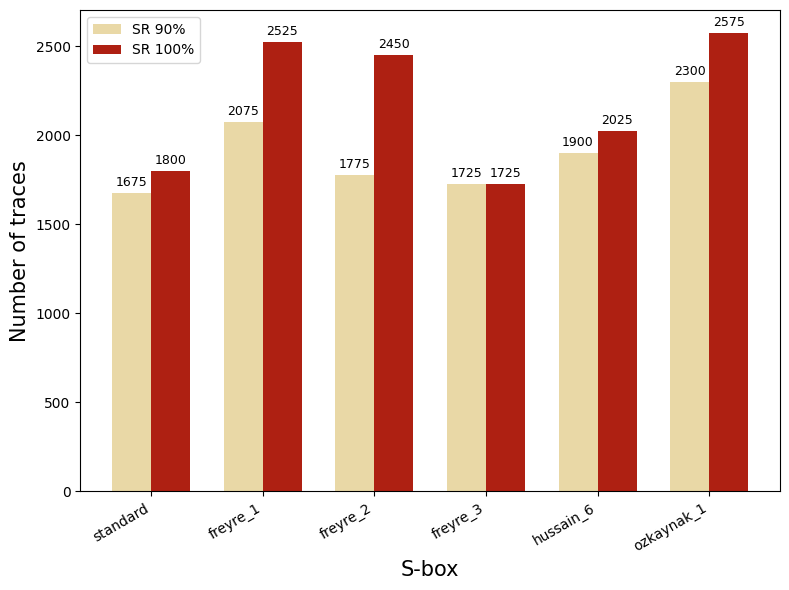

In [ ]:

# For plotting: map "rijndael" to "standard" in the x-axis labels
sboxes_plot = ["standard", "freyre_1", "freyre_2", "freyre_3", "hussain_6", "ozkaynak_1"]

# ----------------------------------------------------------------------
# Plot: grouped bar chart (SR 0.9 vs SR 1.0 stabilization traces)
# ----------------------------------------------------------------------
x = np.arange(len(sboxes_plot))  # the label locations
width = 0.35                     # width of each bar

fig, ax = plt.subplots(figsize=(8, 6))

software_traces = x_90   # SR 90%
hardware_traces = x_100  # SR 100%

rects1 = ax.bar(x - width/2, software_traces, width,
                label="SR 90%", color="#E9D8A6")
rects2 = ax.bar(x + width/2, hardware_traces, width,
                label="SR 100%", color="#AE2012")

# Axis labels and ticks
ax.set_ylabel("Number of traces", fontsize=15)
ax.set_xlabel("S-box", fontsize=15)
ax.set_xticks(x)
ax.set_xticklabels(sboxes_plot, rotation=30, ha="right")
ax.tick_params(axis="y", labelcolor="black", labelsize=10)
ax.tick_params(axis="x", labelsize=10)

# Legend
ax.legend()

# Add values on top of each bar
def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        if np.isnan(height):
            continue
        ax.annotate(f"{int(height)}",
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha="center", va="bottom", fontsize=9)

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.savefig("SR_AES_HW.pdf")
plt.show()
plt.close()